# Filter Sequences Per Hamming Distance

This notebook loads protein evolution datasets, computes Hamming-distance-based statistics, applies a biologically motivated filter, and exports balanced FASTA subsets grouped by distance intervals.

## 1) Environment Setup and Imports

This section imports Python libraries and project-specific modules, configures devices/dtypes, and defines Matplotlib styling for publication-like figures.

In [2]:
# Standard library imports used for paths, regex parsing, and simple counting utilities.
import sys
import re
from pathlib import Path
from collections import Counter

# Add the local src folder so notebook can import project modules.
sys.path.append("../../src/")

# Local project imports.
import functions
from functions import *

# Third-party scientific stack imports.
import torch
import torch.nn as nn
from torch import topk
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

# adabmDCA package imports for sequence handling and statistics.
from adabmDCA.fasta import get_tokens, write_fasta, import_from_fasta, encode_sequence, compute_weights
from adabmDCA.utils import get_device, get_dtype
from adabmDCA.stats import get_freq_single_point, get_freq_two_points, get_correlation_two_points
from adabmDCA.dataset import DatasetDCA
from adabmDCA.functional import one_hot
from adabmDCA.statmech import compute_energy
from adabmDCA.io import load_params

# arDCA paths/model imports used by other analyses in this environment.
import arDCA_paths
from arDCA_paths import arDCA_paths
from arDCA_paths.models import energy_third, energy_third_conditioned_first

# Transformer-related imports used in the broader project workflow.
# from ProteinsDataset import ProteinTranslationDataset
# from ProteinTransformer import *
import json

# Configure CPU and CUDA devices and a default float precision.
device = get_device("cpu")
device2 = get_device("cuda")
dtype = get_dtype("float32")

# Configure Matplotlib for publication-style plots (LaTeX labels, serif fonts, inward ticks).
plt.rcParams.update({
    "text.usetex": True,

})

Running on CPU
Running on NVIDIA RTX A4000


## 2) Load Datasets and Build a Single Matrix

This section defines input FASTA files, loads all sequences, concatenates them into one array, and infers region length $L$ (first, middle, and last segments are assumed to have equal length).

In [ ]:
# Define amino-acid + gap alphabet and map it to model tokens.
data_type = "ACDEFGHIKLMNPQRSTVWY-"
tokens = get_tokens(data_type)

# Select which split to process.
train_or_test = "test"  # or "train"

# List FASTA files collected at multiple evolutionary timescales.
paths_data = [
   # Chorismate Mutase

    # "generated_data/CM/train_validation/10e1_validation.fasta",
    # "generated_data/CM/train_validation/10e2_validation.fasta",
    # "generated_data/CM/train_validation/10e3_validation.fasta",
    # "generated_data/CM/train_validation/10e4_validation.fasta",
    # "generated_data/CM/train_validation/10e5_validation.fasta",
    # "generated_data/CM/train_validation/10e6_validation.fasta"


    # "generated_data/CM/train_validation/10e1_train.fasta",
    # "generated_data/CM/train_validation/10e2_train.fasta",
    # "generated_data/CM/train_validation/10e3_train.fasta",
    # "generated_data/CM/train_validation/10e4_train.fasta",
    # "generated_data/CM/train_validation/10e5_train.fasta",
    # "generated_data/CM/train_validation/10e6_train.fasta"


    "../generated_data/PF00072_2nd/train_validation/10e1_train.fasta",
    "../generated_data/PF00072_2nd/train_validation/10e2_train.fasta", 
    "../generated_data/PF00072_2nd/train_validation/10e3_train.fasta",
    "../generated_data/PF00072_2nd/train_validation/10e4_train.fasta", 
    "../generated_data/PF00072_2nd/train_validation/10e5_train.fasta",
    "../generated_data/PF00072_2nd/train_validation/10e6_train.fasta", 


    # "generated_data/PF00072_2nd/train_validation/10e1_validation.fasta",
    # "generated_data/PF00072_2nd/train_validation/10e2_validation.fasta", 
    # "generated_data/PF00072_2nd/train_validation/10e3_validation.fasta",
    # "generated_data/PF00072_2nd/train_validation/10e4_validation.fasta", 
    # "generated_data/PF00072_2nd/train_validation/10e5_validation.fasta",
    # "generated_data/PF00072_2nd/train_validation/10e6_validation.fasta", 


 ]

# Start with an empty array, then stack all loaded sequence matrices.
data = np.array([])

for path in paths_data:
    # Import encoded sequences from each FASTA file.
    _, x = import_from_fasta(path, tokens)
    if data.size == 0:
        data = x
    else:
        data = np.vstack((data, x))

# Each sequence is split into three equal-length blocks: [0], [T/2], [T].
L = data.shape[1] // 3



# Save each balanced subset into a FASTA file grouped by distance interval (filtered branch).
import os

output_dir_filtered = "generated_data/PF00072_2nd/reorganized_per_distance/new_filtering/filtered/"
os.makedirs(output_dir_filtered, exist_ok=True)


output_dir_non_filtered = "generated_data/PF00072_2nd/reorganized_per_distance/new_filtering/non_filtered/"
os.makedirs(output_dir_non_filtered, exist_ok=True)



output_dir_non_filtered_no_cap = "generated_data/CM/reorganized_per_distance/new_filtering/non_filtered_no_cap/"
os.makedirs(output_dir_non_filtered_no_cap, exist_ok=True)

In [7]:
L

112

## 3) Compute Distance Metrics and Filtering Mask

This section computes two Hamming distances: $d(0,T)$ and $d(0,T/2)$, then builds a mask that keeps sequences with positive relative increase from midpoint to endpoint.

In [5]:
# Compute Hamming distance between the initial state (0) and final state (T).
d = L - (data[:, :L] == data[:, L:2 * L]).sum(1)

# Compute Hamming distance between the initial state (0) and midpoint state (T/2).
d_0_T2 = L - (data[:, :L] == data[:, 2 * L:3 * L]).sum(1)

# Keep sequences where the relative distance increase from T/2 to T is positive.
mask = (d - d_0_T2) / d > 0.

/tmp/ipykernel_52100/499924079.py:8: RuntimeWarning: divide by zero encountered in divide
  mask = (d - d_0_T2) / d > 0.
/tmp/ipykernel_52100/499924079.py:8: RuntimeWarning: invalid value encountered in divide
  mask = (d - d_0_T2) / d > 0.


(array([6.6634e+04, 3.5250e+03, 4.1910e+03, 2.0920e+04, 2.8933e+04,
        1.3485e+04, 2.2660e+03, 5.5000e+01, 1.9200e+02, 1.4900e+03,
        5.7350e+03, 1.3901e+04, 2.5334e+04, 4.4355e+04, 4.5560e+04,
        5.9057e+04, 5.6030e+04, 2.4642e+04, 3.6070e+03, 8.8000e+01]),
 array([  0.  ,   5.15,  10.3 ,  15.45,  20.6 ,  25.75,  30.9 ,  36.05,
         41.2 ,  46.35,  51.5 ,  56.65,  61.8 ,  66.95,  72.1 ,  77.25,
         82.4 ,  87.55,  92.7 ,  97.85, 103.  ]),
 <BarContainer object of 20 artists>)

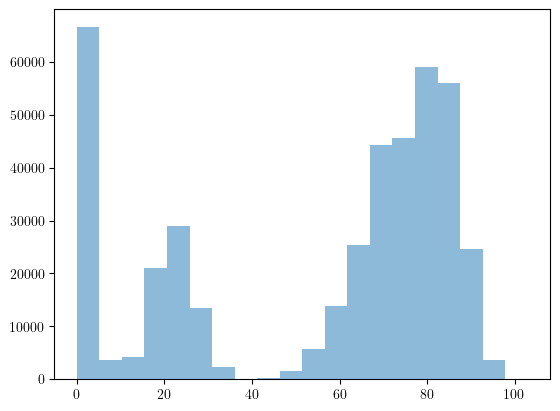

In [9]:
plt.hist(d, bins=20, alpha=0.5, label="d(0,T)")

## 4) Count Sequences Per Distance Bin

This section counts how many sequences fall into each Hamming-distance bin for full and filtered data, then derives a conservative per-bin cap to balance sampling.

In [6]:
# Store histogram counts per distance value for full data and masked data.
n_per_bin = []
n_per_bin_flt = []

for i in range(max(d) + 1):
    n_per_bin.append(np.sum(d == i))
    n_per_bin_flt.append(np.sum(d[mask] == i))

n_per_bin = np.array(n_per_bin)
n_per_bin_flt = np.array(n_per_bin_flt)

# Choose a conservative cap per distance (rounded down to the nearest 100).
num_seq_max = np.min(n_per_bin[1:70]) // 100 * 100
num_seq_max_flt = np.min(n_per_bin_flt[1:70]) // 100 * 100

print(num_seq_max)
print(num_seq_max_flt)

0
0


## 5) Visual Diagnostics Before Filtering

These plots compare full vs filtered distributions and show how $d(0,T/2)$ and $d(0,T)$ are jointly distributed.

/tmp/ipykernel_52100/1350000962.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=12, bbox_to_anchor=(1.05, 1), loc="upper left")


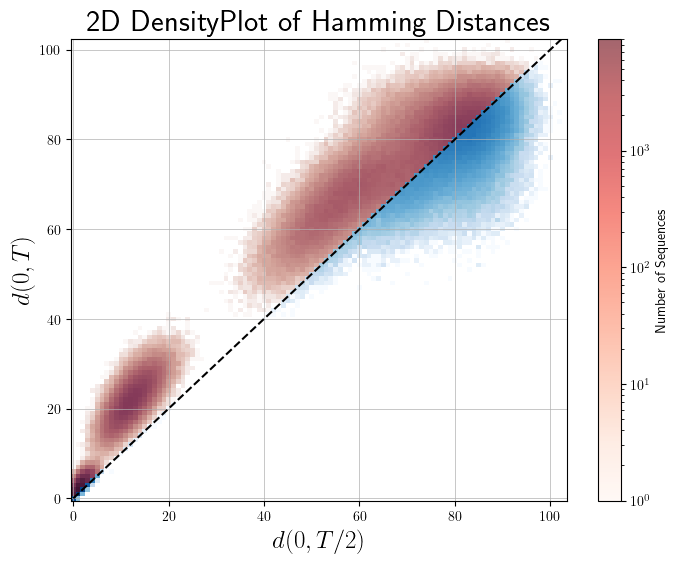

In [10]:
# Compare the 2D density of distances before and after masking.
plt.figure(figsize=(8, 6))

# Full dataset density in blue.
plt.hist2d(
    d_0_T2,
    d,
    bins=[np.arange(-0.5, max(d) + 1.5, 1), np.arange(-0.5, max(d_0_T2) + 1.5, 1)],
    cmap="Blues",
    norm="log"
 )

# Filtered dataset density in red (semi-transparent overlay).
plt.hist2d(
    d_0_T2[mask],
    d[mask],
    bins=[np.arange(-0.5, max(d) + 1.5, 1), np.arange(-0.5, max(d_0_T2) + 1.5, 1)],
    cmap="Reds",
    norm="log",
    alpha=0.6
 )

# Diagonal reference line (equal distances).
plt.plot([0, max(d)], [0, max(d)], color="black", linestyle="--")

plt.legend(fontsize=12, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.colorbar(label="Number of Sequences")
plt.xlabel(r"$d(0,T/2)$", fontsize=18)
plt.ylabel(r"$d(0,T)$", fontsize=18)
plt.title("2D DensityPlot of Hamming Distances", fontsize=22)
plt.grid(True, which="both", linewidth=0.5)

# plt.savefig(f"hamming_distance_2D_density_{train_or_test}_fltr_relative.png")
plt.show()

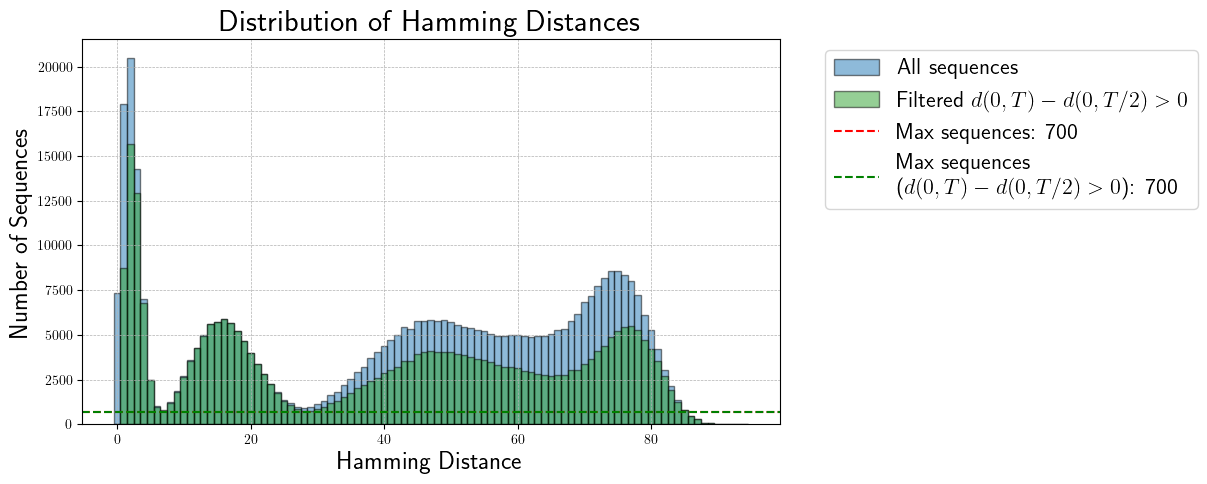

In [91]:
# Plot 1D distance distributions for full vs filtered datasets.
plt.figure(figsize=(9, 5))

# Histogram for all sequences.
plt.hist(
    d,
    bins=np.arange(-0.5, max(d) + 1.5, 1),
    color="C0",
    alpha=0.5,
    edgecolor="black",
    label="All sequences"
 )

# Histogram for sequences passing the relative-distance filter.
plt.hist(
    d[mask],
    bins=np.arange(-0.5, max(d) + 1.5, 1),
    color="C2",
    alpha=0.5,
    edgecolor="black",
    label=r"Filtered $d(0,T) - d(0,T/2) > 0$"
 )

# Horizontal lines indicate the balancing caps used later for sampling.
plt.axhline(y=num_seq_max, color="r", linestyle="--", label=f"Max sequences: {num_seq_max}")
plt.axhline(
    y=num_seq_max_flt,
    color="g",
    linestyle="--",
    label=f"Max sequences \n($d(0,T) - d(0,T/2) > 0$): {num_seq_max_flt}"
 )

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=16)
plt.xlabel("Hamming Distance", fontsize=18)
plt.ylabel("Number of Sequences", fontsize=18)
plt.title("Distribution of Hamming Distances", fontsize=22)
plt.grid(True, which="both", ls="--", linewidth=0.5)

# plt.savefig(f"hamming_distance_distribution_{train_or_test}_fltr_relative.png")
plt.show()

## 6) Build Balanced Subsets by Distance Intervals

This section creates distance intervals, samples an equal number of sequences per distance, and stores both unmasked and masked balanced subsets.

In [92]:
# Build closed-open distance intervals: [1,6), [6,11), ..., [66,71).
intervals_save = [(i, i + 5) for i in range(1, 70, 5)]

# Dictionaries storing balanced subsets (all data vs masked data).
data_filtered = {}
data_filtered_mask = {}

for _, (left, right) in enumerate(intervals_save):
    print(f"Processing distance interval: {left} to {right - 1}")

    # Initialize empty 2D arrays for this interval endpoint key.
    data_filtered[right] = np.empty((0, data.shape[1]), dtype=data.dtype)
    data_filtered_mask[right] = np.empty((0, data.shape[1]), dtype=data.dtype)

    for i in range(left, right):
        # Select sequences at exact distance i.
        data_to_filter = data[d == i]
        data_mask_to_filter = data[mask & (d == i), :]

        print(
            f"Distance {i}: {data_to_filter.shape[0]} sequences, "
            f"{data_mask_to_filter.shape[0]} filtered sequences"
        )

        # Randomly subsample each bin to a common cap for balanced datasets.
        if (data_to_filter.shape[0] > num_seq_max) & (data_mask_to_filter.shape[0] > num_seq_max_flt):
            indices = np.random.choice(data_to_filter.shape[0], num_seq_max, replace=False)
            indices_mask = np.random.choice(data_mask_to_filter.shape[0], num_seq_max_flt, replace=False)

            data_filtered[right] = np.concatenate((data_filtered[right], data_to_filter[indices]))
            data_filtered_mask[right] = np.concatenate((data_filtered_mask[right], data_mask_to_filter[indices_mask]))
        else:
            # Fail fast if a bin does not contain enough sequences for balancing.
            raise ValueError(" --- There is a problem with the data --- ")

Processing distance interval: 1 to 5
Distance 1: 17925 sequences, 8753 filtered sequences
Distance 2: 20506 sequences, 15653 filtered sequences
Distance 3: 14250 sequences, 12938 filtered sequences
Distance 4: 6984 sequences, 6765 filtered sequences
Distance 5: 2487 sequences, 2450 filtered sequences
Processing distance interval: 6 to 10
Distance 6: 1008 sequences, 972 filtered sequences
Distance 7: 786 sequences, 728 filtered sequences
Distance 8: 1246 sequences, 1196 filtered sequences
Distance 9: 1863 sequences, 1818 filtered sequences
Distance 10: 2713 sequences, 2665 filtered sequences
Processing distance interval: 11 to 15
Distance 11: 3582 sequences, 3544 filtered sequences
Distance 12: 4272 sequences, 4249 filtered sequences
Distance 13: 4975 sequences, 4956 filtered sequences
Distance 14: 5590 sequences, 5581 filtered sequences
Distance 15: 5718 sequences, 5707 filtered sequences
Processing distance interval: 16 to 20
Distance 16: 5887 sequences, 5885 filtered sequences
Distan

## 7) Validate Filtered Subsets

This check ensures the filtered balanced subsets satisfy the expected constraint $d(0,T)-d(0,T/2)\ge 0$ for every saved interval.

In [93]:
# Validate that all masked balanced subsets satisfy d(0,T) - d(0,T/2) >= 0.
all_d_0_T = np.array([])
all_d_0_T2 = np.array([])

for key in data_filtered_mask.keys():
    # Recompute distances for each stored subset.
    d_T2 = L - (data_filtered_mask[key][:, :L] == data_filtered_mask[key][:, 2 * L:3 * L]).sum(1)
    d_0_T = L - (data_filtered_mask[key][:, :L] == data_filtered_mask[key][:, L:2 * L]).sum(1)

    # Accumulate for a global visualization in the next cell.
    all_d_0_T = np.concatenate((all_d_0_T, d_0_T))
    all_d_0_T2 = np.concatenate((all_d_0_T2, d_T2))

    delta_d = d_0_T - d_T2
    if np.any(delta_d < 0):
        raise ValueError(f" --- Filtered data check failed for key {key} --- ")
    else:
        print(f" --- All delta distances are non-negative for key {key} --- ")

 --- All delta distances are non-negative for key 6 --- 
 --- All delta distances are non-negative for key 11 --- 
 --- All delta distances are non-negative for key 16 --- 
 --- All delta distances are non-negative for key 21 --- 
 --- All delta distances are non-negative for key 26 --- 
 --- All delta distances are non-negative for key 31 --- 
 --- All delta distances are non-negative for key 36 --- 
 --- All delta distances are non-negative for key 41 --- 
 --- All delta distances are non-negative for key 46 --- 
 --- All delta distances are non-negative for key 51 --- 
 --- All delta distances are non-negative for key 56 --- 
 --- All delta distances are non-negative for key 61 --- 
 --- All delta distances are non-negative for key 66 --- 
 --- All delta distances are non-negative for key 71 --- 


/tmp/ipykernel_1422865/1881255834.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=12, bbox_to_anchor=(1.05, 1), loc="upper left")


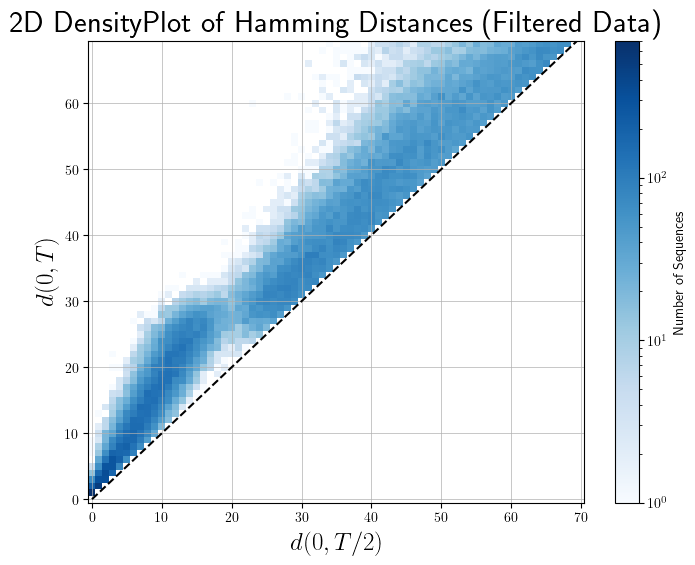

In [94]:
# Plot 2D density of distances on the concatenated filtered balanced subsets.
plt.figure(figsize=(8, 6))
plt.hist2d(
    all_d_0_T2,
    all_d_0_T,
    bins=[np.arange(-0.5, max(all_d_0_T) + 1.5, 1), np.arange(-0.5, max(all_d_0_T2) + 1.5, 1)],
    cmap="Blues",
    norm="log"
 )

# Add diagonal reference line (equal midpoint and endpoint distances).
plt.plot([0, max(all_d_0_T)], [0, max(all_d_0_T)], color="black", linestyle="--")

plt.legend(fontsize=12, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.colorbar(label="Number of Sequences")
plt.xlabel(r"$d(0,T/2)$", fontsize=18)
plt.ylabel(r"$d(0,T)$", fontsize=18)
plt.title("2D DensityPlot of Hamming Distances (Filtered Data)", fontsize=22)
plt.grid(True, which="both", linewidth=0.5)

## 8) Export Balanced FASTA Files

The final step creates the output directory and writes one FASTA file per interval for downstream training/evaluation workflows.

In [ ]:


for key, data_save in data_filtered.items():  # Keep current filtered workflow as in the existing notebook.
    # Build simple sequence headers for FASTA export.
    headers = [f"seq_{j}" for j in range(data_save.shape[0])]

    # Example: distance_5_train.fasta corresponds to interval ending at key=6 (i.e., 1..5).
    path_out = f"{output_dir_filtered}/distance_{key - 1}_train.fasta"

    # Write encoded sequences back to FASTA using the same token alphabet.
    write_fasta(path_out, headers, data_save, False, tokens)

## 9) Build Non-Filtered Balanced Subsets

This branch does not apply `mask`. It uses the same distance binning (`intervals_save`) and subsamples each distance with `num_seq_max`.

In [96]:
# Build non-filtered balanced subsets without applying mask.
data_non_filtered = {}

for _, (left, right) in enumerate(intervals_save):
    print(f"Processing non-filtered interval: {left} to {right - 1}")
    data_non_filtered[right] = np.empty((0, data.shape[1]), dtype=data.dtype)

    for i in range(left, right):
        # Select all sequences at exact Hamming distance i (no mask).
        data_to_sample = data[d == i]
        print(f"Distance {i}: {data_to_sample.shape[0]} non-filtered sequences")

        # Subsample each distance bin to num_seq_max for balanced non-filtered data.
        if data_to_sample.shape[0] >= num_seq_max:
            indices = np.random.choice(data_to_sample.shape[0], num_seq_max, replace=False)
            data_non_filtered[right] = np.concatenate((data_non_filtered[right], data_to_sample[indices]))
        else:
            raise ValueError(
                f"Not enough non-filtered sequences at distance {i}: "
                f"{data_to_sample.shape[0]} < {num_seq_max}"
            )

Processing non-filtered interval: 1 to 5
Distance 1: 17925 non-filtered sequences
Distance 2: 20506 non-filtered sequences
Distance 3: 14250 non-filtered sequences
Distance 4: 6984 non-filtered sequences
Distance 5: 2487 non-filtered sequences
Processing non-filtered interval: 6 to 10
Distance 6: 1008 non-filtered sequences
Distance 7: 786 non-filtered sequences
Distance 8: 1246 non-filtered sequences
Distance 9: 1863 non-filtered sequences
Distance 10: 2713 non-filtered sequences
Processing non-filtered interval: 11 to 15
Distance 11: 3582 non-filtered sequences
Distance 12: 4272 non-filtered sequences
Distance 13: 4975 non-filtered sequences
Distance 14: 5590 non-filtered sequences
Distance 15: 5718 non-filtered sequences
Processing non-filtered interval: 16 to 20
Distance 16: 5887 non-filtered sequences
Distance 17: 5678 non-filtered sequences
Distance 18: 5216 non-filtered sequences
Distance 19: 4681 non-filtered sequences
Distance 20: 3984 non-filtered sequences
Processing non-fil

## 10) Export Non-Filtered FASTA Files

This section saves non-filtered balanced subsets into a separate `non_filtered` subfolder.

In [ ]:
# Export non-filtered balanced subsets into a dedicated subfolder.


for key, data_save in data_non_filtered.items():
    headers = [f"seq_{j}" for j in range(data_save.shape[0])]
    path_out = f"{output_dir_non_filtered}/distance_{key - 1}_train.fasta"
    write_fasta(path_out, headers, data_save, False, tokens)

## 11) Export Non-Filtered Sequences Without Cap

This branch keeps all non-filtered sequences in each distance bin (no `num_seq_max` subsampling) and saves them in a dedicated folder.

In [ ]:


for _, (left, right) in enumerate(intervals_save):
    # Collect all sequences from distances in the current interval [left, right).
    data_interval = np.empty((0, data.shape[1]), dtype=data.dtype)
    for i in range(left, right):
        data_interval = np.concatenate((data_interval, data[d == i]))

    # Save every sequence in the interval without subsampling.
    headers = [f"seq_{j}" for j in range(data_interval.shape[0])]
    path_out = f"{output_dir_non_filtered_no_cap}/distance_{right - 1}_train.fasta"
    write_fasta(path_out, headers, data_interval, False, tokens)

In [99]:
# End of notebook.
# Optional: add downstream checks or model-training hooks here.